# MIE1517 Project — RNN Baseline: Spatial Patch-Sequence BiLSTM
**Binary Classification: Benign (0) vs Malignant (1)**

## Overview & Motivation

### Why an RNN-based Baseline?

The primary CNN model uses a **DenseNet-121 + EfficientNet-B4** hybrid that applies global average pooling over the entire feature map before classification. While powerful, global pooling **discards all spatial layout information** — it cannot model how different regions of a lesion relate to each other spatially (e.g., irregular borders near the centre, colour asymmetry across quadrants, or texture gradients radiating from the lesion core).

An RNN is well-suited to model ordered sequential dependencies. Applied to images, the key insight is:

> A pretrained CNN backbone produces a **7×7 spatial feature map** over the lesion. Each of the 49 spatial positions captures a local receptive field. Reading these 49 positions in raster order defines a **natural spatial sequence** that an RNN can model — learning which spatial transitions (centre→border, top→bottom) are most diagnostically relevant.

This architecture is fundamentally different from the CNN baseline and serves as a meaningful comparison: if the BiLSTM substantially outperforms or underperforms the global-pooling CNN, it tells us whether **spatial ordering and locality** are informative beyond bag-of-features representations.

---

### Model Architecture: Spatial Patch-Sequence BiLSTM

```
Input Image (224 x 224 x 3)
        |
        v
+-------------------------+
|  ResNet-50 Backbone      |  <- pretrained on ImageNet, fine-tuned
|  (up to layer4, no pool) |
+-------------------------+
        |  7 x 7 x 2048 feature map
        v
   Reshape -> sequence of 49 spatial tokens (each 2048-d)
        |
        v
+-------------------------+
|  2-layer Bidirectional   |  <- BiLSTM captures left<->right context
|  LSTM (hidden = 512)     |     across spatial positions
+-------------------------+
        |  49 x 1024 hidden states
        v
+-------------------------+
|  Additive Attention      |  <- learns which spatial positions
|  Pooling                 |     are most diagnostically relevant
+-------------------------+
        |  1024-d context vector
        v  concat
+-------------------------+
|  Metadata Embedding      |  <- tbp_lv_dnn_lesion_confidence,
|  Module (-> 32-d)        |     iddx_1, attribution,
+-------------------------+     mel_thick_mm, mel_mitotic_index
        |  1056-d fused vector
        v
  BatchNorm -> Dropout -> FC(512) -> ReLU -> Dropout -> FC(1)
        |
        v
   Logit -> sigmoid -> P(malignant)  [binary: 0=Benign, 1=Malignant]
```

---

### Techniques Applied

- **ResNet-50 transfer learning** — ImageNet-pretrained backbone provides rich low/mid-level visual features without training from scratch
- **Spatial feature map as sequence** — the 7×7 conv output (49 positions) converts a 2-D feature map into a 1-D sequence suitable for RNN processing
- **Bidirectional LSTM (2 layers)** — models forward and backward spatial dependencies simultaneously; 2 layers capture both local texture and global lesion structure
- **Additive attention pooling** — replaces fixed global pooling with a learned weighted sum, allowing the model to focus on diagnostically suspicious spatial regions
- **Clinical metadata fusion** — supplement CSV features (DNN confidence score, differential diagnosis, institution, melanoma measurements) are embedded and fused at the classifier stage, adding domain knowledge beyond visual appearance
- **Focal Loss (gamma=2, alpha=0.25)** — addresses extreme class imbalance (~98% benign) by down-weighting easy negatives and concentrating gradient on hard malignant examples; superior to weighted BCE for severe imbalance
- **WeightedRandomSampler** — ensures each mini-batch contains both classes in a balanced ratio, stabilising early training
- **Decision threshold calibration** — the optimal threshold is found by maximising F1 on the validation set rather than using the default 0.5, improving the sensitivity/specificity trade-off for the minority class
- **AUPRC metric** — Area under the Precision-Recall Curve is reported alongside AUC-ROC; AUPRC is more informative than ROC-AUC under severe class imbalance since it is not dominated by the large true-negative count

## Imports

In [1]:
import os
import random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.models as models
import torchvision.transforms as T

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Reproducibility
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## Configuration

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
ROOT       = Path(".")
IMAGE_DIR  = ROOT / "ISIC_2024_Training_Input"
GT_CSV     = ROOT / "ISIC_2024_Training_GroundTruth.csv"
SUPP_CSV   = ROOT / "ISIC_2024_Training_Supplement.csv"

# ── Data split ratios ──────────────────────────────────────────────────────
TRAIN_RATIO = 0.60   # 60% train / 20% val / 20% test

# ── Image settings ─────────────────────────────────────────────────────────
IMAGE_SIZE   = 224   # ResNet-50 spatial output will be 7×7

# ── BiLSTM settings ────────────────────────────────────────────────────────
LSTM_HIDDEN  = 512   # hidden size per direction; bidirectional → 1024 total
LSTM_LAYERS  = 2     # stacked BiLSTM layers
META_DIM     = 32    # projected metadata embedding dimension

# ── Training hyperparameters ───────────────────────────────────────────────
BATCH_SIZE   = 32
NUM_EPOCHS   = 20
LR           = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT      = 0.4

# ── Focal Loss hyperparameters ─────────────────────────────────────────────
FOCAL_GAMMA  = 2.0   # focusing parameter (2 is standard for medical imaging)
FOCAL_ALPHA  = 0.25  # weight on positive (malignant) class

# NOTE: num_workers > 0 deadlocks on Windows inside a Jupyter notebook (spawn issue)
NUM_WORKERS  = 0

# ── Optional: subsample for fast iteration (1.0 = full dataset) ────────────
SAMPLE_FRACTION = 1.0

## Data Loading & Feature Engineering

### Supplement CSV Features Used

The `ISIC_2024_Training_Supplement.csv` provides clinical metadata for each lesion. After examining all 13 columns, five are selected as model inputs:

- `tbp_lv_dnn_lesion_confidence` (Float 0–100) — normalized to [0, 1]; always populated for every sample
- `iddx_1` (Categorical, ~15 values) — primary differential diagnosis; label-encoded to an integer index for `nn.Embedding`
- `attribution` (Categorical, ~10 institutions) — data source institution; label-encoded to an integer index for `nn.Embedding`
- `mel_thick_mm` (Float, sparse) — melanoma thickness in mm; missing values imputed with 0 then normalized
- `mel_mitotic_index` (Float, sparse) — melanoma mitotic index; missing values imputed with 0 then normalized

Columns excluded:
- `lesion_id` — ~90% empty, no usable patient grouping
- `iddx_2` through `iddx_5` — >95% empty
- `iddx_full` — redundant with `iddx_1`
- `copyright_license` — not clinically relevant

C:\Users\AnCYu\AppData\Local\Temp\ipykernel_32000\589263280.py:3: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  supp = pd.read_csv(SUPP_CSV)


Samples with images : 401,059
Malignant           : 393  (0.10%)
mel_mitotic_index dtype : float64
mel_thick_mm dtype      : float64
iddx_1 categories  : 3  -> ['Benign', 'Indeterminate', 'Malignant']
attribution sites  : 7


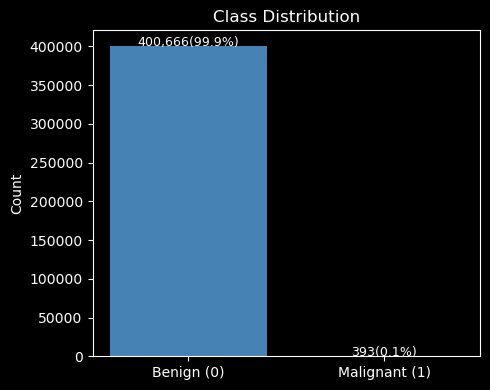

In [7]:
# ---- Load and merge CSVs ------------------------------------------------
gt   = pd.read_csv(GT_CSV)
supp = pd.read_csv(SUPP_CSV)
df   = gt.merge(supp[["isic_id", "tbp_lv_dnn_lesion_confidence",
                        "iddx_1", "attribution",
                        "mel_thick_mm", "mel_mitotic_index"]],
                on="isic_id", how="left")
df["malignant"] = df["malignant"].astype(int)

# ---- Keep only rows whose image exists ----------------------------------
df["img_path"] = df["isic_id"].apply(lambda x: IMAGE_DIR / f"{x}.jpg")
df = df[df["img_path"].apply(lambda p: p.exists())].reset_index(drop=True)
print(f"Samples with images : {len(df):,}")
print(f"Malignant           : {df['malignant'].sum():,}  ({df['malignant'].mean()*100:.2f}%)")

# ---- Parse mel_mitotic_index -------------------------------------------
# The column is stored as strings (e.g. "0/mm^2", "<1/mm^2", ">4/mm^2").
# Strip the unit and map boundary tokens to numeric mid-point values.
def parse_mitotic_index(val) -> float:
    if pd.isna(val):
        return 0.0
    s = str(val).replace("/mm^2", "").strip()
    if s.startswith("<"):
        return float(s[1:]) * 0.5   # e.g. "<1" -> 0.5
    if s.startswith(">"):
        return float(s[1:]) + 1.0   # e.g. ">4" -> 5.0
    try:
        return float(s)
    except ValueError:
        return 0.0

df["mel_mitotic_index"] = df["mel_mitotic_index"].apply(parse_mitotic_index)
df["mel_thick_mm"]      = pd.to_numeric(df["mel_thick_mm"], errors="coerce").fillna(0.0)

# ---- Normalise numeric metadata features --------------------------------
df["tbp_conf_norm"]  = (df["tbp_lv_dnn_lesion_confidence"] / 100.0).clip(0.0, 1.0)
df["thick_norm"]     = df["mel_thick_mm"]      / (df["mel_thick_mm"].max()      + 1e-8)
df["mitotic_norm"]   = df["mel_mitotic_index"] / (df["mel_mitotic_index"].max() + 1e-8)

print(f"mel_mitotic_index dtype : {df['mel_mitotic_index'].dtype}")
print(f"mel_thick_mm dtype      : {df['mel_thick_mm'].dtype}")

# ---- Label-encode categorical features ----------------------------------
le_iddx = LabelEncoder()
le_attr = LabelEncoder()

df["iddx_1"]      = df["iddx_1"].fillna("Unknown")
df["attribution"] = df["attribution"].fillna("Unknown")

df["iddx1_enc"] = le_iddx.fit_transform(df["iddx_1"])
df["attr_enc"]  = le_attr.fit_transform(df["attribution"])

N_IDDX = len(le_iddx.classes_)
N_ATTR = len(le_attr.classes_)
print(f"iddx_1 categories  : {N_IDDX}  -> {list(le_iddx.classes_)}")
print(f"attribution sites  : {N_ATTR}")

# ---- Optional sub-sampling ----------------------------------------------
if SAMPLE_FRACTION < 1.0:
    df = df.groupby("malignant", group_keys=False).apply(
        lambda g: g.sample(frac=SAMPLE_FRACTION, random_state=SEED)
    ).reset_index(drop=True)
    print(f"After sampling ({SAMPLE_FRACTION:.0%}): {len(df):,} samples")

# ---- Class distribution plot --------------------------------------------
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["malignant"].value_counts().sort_index()
ax.bar(["Benign (0)", "Malignant (1)"], counts.values, color=["steelblue", "tomato"])
ax.set_ylabel("Count")
ax.set_title("Class Distribution")
for i, v in enumerate(counts.values):
    ax.text(i, v + 200, f"{v:,}({v/len(df)*100:.1f}%)", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## Dataset Class

Each sample returns a tuple of **(image tensor, metadata dict, label)**. The metadata dict carries both the integer categorical indices (for embedding lookup) and the three normalized numeric features (for direct concatenation).

In [8]:
class SkinLesionRNNDataset(Dataset):
    """
    Returns (image_tensor, metadata, label) triples.

    metadata is a dict:
        'iddx1'   : LongTensor(1)   - encoded iddx_1 index
        'attr'    : LongTensor(1)   - encoded attribution index
        'numeric' : FloatTensor(3)  - [tbp_conf_norm, thick_norm, mitotic_norm]
    """
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row["img_path"]).convert("RGB")
        if self.transform:
            image = self.transform(image)

        meta = {
            "iddx1"  : torch.tensor(int(row["iddx1_enc"]), dtype=torch.long),
            "attr"   : torch.tensor(int(row["attr_enc"]),  dtype=torch.long),
            "numeric": torch.tensor(
                [row["tbp_conf_norm"], row["thick_norm"], row["mitotic_norm"]],
                dtype=torch.float32
            ),
        }
        label = torch.tensor(row["malignant"], dtype=torch.float32)
        return image, meta, label

## Train / Validation / Test Split & Class Imbalance Handling

### Why WeightedRandomSampler?

The dataset is severely imbalanced (~98% benign). Without intervention, the model would learn to predict "benign" for everything and achieve >98% accuracy while completely missing malignant cases. `WeightedRandomSampler` oversamples the minority (malignant) class so each mini-batch is approximately balanced, ensuring the model receives sufficient gradient signal from malignant examples during every update.

In [9]:
# ── Stratified 60 / 20 / 20 split ─────────────────────────────────────────
df_train, df_temp = train_test_split(
    df, test_size=(1 - TRAIN_RATIO), stratify=df["malignant"], random_state=SEED
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.5, stratify=df_temp["malignant"], random_state=SEED
)
print(f"Train : {len(df_train):>7,}  ({df_train['malignant'].mean()*100:.2f}% malignant)")
print(f"Val   : {len(df_val):>7,}  ({df_val['malignant'].mean()*100:.2f}% malignant)")
print(f"Test  : {len(df_test):>7,}  ({df_test['malignant'].mean()*100:.2f}% malignant)")

# ── Transforms ────────────────────────────────────────────────────────────
_MEAN = [0.485, 0.456, 0.406]
_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    T.RandomCrop(IMAGE_SIZE),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.RandomRotation(20),
    T.ToTensor(),
    T.Normalize(_MEAN, _STD),
])
eval_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(_MEAN, _STD),
])

# ── Datasets ──────────────────────────────────────────────────────────────
train_dataset = SkinLesionRNNDataset(df_train, transform=train_transform)
val_dataset   = SkinLesionRNNDataset(df_val,   transform=eval_transform)
test_dataset  = SkinLesionRNNDataset(df_test,  transform=eval_transform)

# ── WeightedRandomSampler ──────────────────────────────────────────────────
n_benign    = (df_train["malignant"] == 0).sum()
n_malignant = (df_train["malignant"] == 1).sum()
cw = {0: 1.0 / n_benign, 1: 1.0 / n_malignant}
sample_weights = df_train["malignant"].map(cw).values
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# ── DataLoaders ────────────────────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=NUM_WORKERS, pin_memory=True)

print(f"\nTrain batches: {len(train_loader)}, Val batches: {len(val_loader)}, "
      f"Test batches: {len(test_loader)}")

Train : 240,635  (0.10% malignant)
Val   :  80,212  (0.10% malignant)
Test  :  80,212  (0.10% malignant)

Train batches: 7520, Val batches: 2507, Test batches: 2507


## Model Architecture

### ResNet-50 → Spatial Sequence → BiLSTM with Attention

The model has three stages:

**Stage 1 — Feature Extraction (ResNet-50 backbone)**
ResNet-50 pretrained on ImageNet is used up to its final convolutional block (`layer4`), stopping before the average pooling layer. For a 224×224 input, this produces a **7×7×2048** feature map. Each of the 49 spatial cells covers a 32×32 receptive field in the original image, capturing local texture and shape around that region.

**Stage 2 — Sequential Modelling (Bidirectional LSTM)**
The 7×7 feature map is reshaped into a **49-step sequence** (raster scan: row-by-row). A 2-layer Bidirectional LSTM processes this sequence. Using both forward and backward passes ensures each spatial position's representation is informed by all other positions — not just those that came before it in the scan order. This bidirectionality is important because lesion features (e.g., colour change at the border) are spatially symmetric and have no preferred direction.

**Stage 3 — Attention Pooling + Metadata Fusion**
Rather than just taking the final LSTM state, an **additive (Bahdanau-style) attention** mechanism computes a scalar score for each of the 49 positions and produces a weighted sum. This allows the model to focus on the most diagnostically suspicious spatial regions. The resulting context vector is then concatenated with a **metadata embedding** (clinical supplement features) before the final MLP classifier.

In [10]:
class MetadataEmbedder(nn.Module):
    """
    Encodes clinical supplement features into a fixed-size vector.
    Categorical features → nn.Embedding; numeric features → direct concat.
    Output: META_DIM-dimensional vector.
    """
    def __init__(self, n_iddx: int, n_attr: int, meta_dim: int = META_DIM):
        super().__init__()
        emb_iddx = max(4, n_iddx // 2)
        emb_attr = max(4, n_attr // 2)

        self.emb_iddx = nn.Embedding(n_iddx, emb_iddx)
        self.emb_attr = nn.Embedding(n_attr, emb_attr)

        in_dim = emb_iddx + emb_attr + 3   # 3 numeric features
        self.proj = nn.Sequential(
            nn.Linear(in_dim, meta_dim),
            nn.ReLU(inplace=True),
        )

    def forward(self, meta: dict) -> torch.Tensor:
        e_iddx   = self.emb_iddx(meta["iddx1"])             # (B, emb_iddx)
        e_attr   = self.emb_attr(meta["attr"])               # (B, emb_attr)
        numeric  = meta["numeric"]                           # (B, 3)
        combined = torch.cat([e_iddx, e_attr, numeric], dim=1)
        return self.proj(combined)                           # (B, meta_dim)


class AdditiveAttention(nn.Module):
    """
    Bahdanau-style additive attention over a sequence.
    Produces a context vector as a weighted sum of encoder states.
    """
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.score = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, lstm_out: torch.Tensor) -> torch.Tensor:
        # lstm_out: (B, seq_len, hidden_dim)
        weights = torch.softmax(self.score(lstm_out), dim=1)  # (B, seq_len, 1)
        context = (weights * lstm_out).sum(dim=1)             # (B, hidden_dim)
        return context


class SpatialBiLSTM(nn.Module):
    """
    Spatial Patch-Sequence Bidirectional LSTM for skin lesion classification.

    Pipeline:
      ResNet-50 (layer4 only, no pool) → 7×7×2048 feature map
      → reshape to sequence (49, 2048)
      → 2-layer BiLSTM
      → additive attention pooling  → 1024-d context
      → concat metadata embedding   → 1024+META_DIM fused vector
      → BatchNorm → Dropout → FC(512) → ReLU → Dropout → FC(1)
    """

    RESNET_OUT = 2048        # channels after ResNet-50 layer4
    SEQ_LEN    = 49          # 7×7 spatial positions

    def __init__(self, n_iddx: int, n_attr: int,
                 lstm_hidden: int = LSTM_HIDDEN,
                 lstm_layers: int = LSTM_LAYERS,
                 meta_dim:    int = META_DIM,
                 dropout:     float = DROPOUT):
        super().__init__()

        # ── ResNet-50 backbone (remove avgpool + fc) ───────────────────────
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.backbone = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool,
            resnet.layer1, resnet.layer2, resnet.layer3, resnet.layer4,
        )   # output: (B, 2048, 7, 7) for 224×224 input

        # ── Bidirectional LSTM ─────────────────────────────────────────────
        self.bilstm = nn.LSTM(
            input_size  = self.RESNET_OUT,
            hidden_size = lstm_hidden,
            num_layers  = lstm_layers,
            batch_first = True,
            bidirectional = True,
            dropout = dropout if lstm_layers > 1 else 0.0,
        )
        bilstm_out_dim = lstm_hidden * 2   # bidirectional

        # ── Attention pooling ──────────────────────────────────────────────
        self.attention = AdditiveAttention(bilstm_out_dim)

        # ── Metadata embedder ──────────────────────────────────────────────
        self.meta_embedder = MetadataEmbedder(n_iddx, n_attr, meta_dim)

        # ── Fusion classifier ──────────────────────────────────────────────
        fused_dim = bilstm_out_dim + meta_dim
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(fused_dim),
            nn.Dropout(dropout),
            nn.Linear(fused_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(512, 1),    # raw logit for Focal Loss
        )

    def forward(self, x: torch.Tensor, meta: dict) -> torch.Tensor:
        # ── Stage 1: CNN feature extraction ───────────────────────────────
        feat = self.backbone(x)                              # (B, 2048, 7, 7)
        B, C, H, W = feat.shape
        seq  = feat.permute(0, 2, 3, 1).reshape(B, H * W, C)  # (B, 49, 2048)

        # ── Stage 2: BiLSTM over spatial sequence ─────────────────────────
        lstm_out, _ = self.bilstm(seq)                       # (B, 49, 1024)

        # ── Stage 3: Attention + metadata fusion ──────────────────────────
        context  = self.attention(lstm_out)                  # (B, 1024)
        meta_vec = self.meta_embedder(meta)                  # (B, meta_dim)
        fused    = torch.cat([context, meta_vec], dim=1)     # (B, 1024+meta_dim)

        return self.classifier(fused).squeeze(1)             # (B,)


# ── Instantiate ────────────────────────────────────────────────────────────
model = SpatialBiLSTM(n_iddx=N_IDDX, n_attr=N_ATTR).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\AnCYu/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 90.5MB/s]


Total parameters    : 40,846,889
Trainable parameters: 40,846,889


## Training Strategy

### Focal Loss — Addressing Extreme Class Imbalance

Standard Binary Cross-Entropy (BCE) treats every sample equally. With ~98% benign samples, the model is flooded with easy "benign" examples during training. Their gradients dominate and suppress learning from the rare, harder malignant cases — even when `pos_weight` is used.

**Focal Loss** (Lin et al., 2017, originally for object detection) adds a modulating factor `(1 − p_t)^γ` to BCE:

```
FL(p_t) = −α · (1 − p_t)^γ · log(p_t)
```

- When a sample is **confidently classified** (high `p_t`), `(1 − p_t)^γ ≈ 0`, so its contribution to the loss is down-weighted almost to zero.
- When a sample is **misclassified or uncertain** (low `p_t`), the factor approaches 1, preserving the full loss signal.

With `γ=2` (standard), a well-classified easy example is weighted 100× less than a hard example. This effectively re-focuses training on the minority malignant class without needing to artificially inflate `pos_weight` to extreme values.

`α=0.25` provides an additional prior weight on the positive (malignant) class, complementing the `WeightedRandomSampler`.

In [11]:
class FocalLoss(nn.Module):
    """
    Binary Focal Loss.
    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
    Accepts raw logits (applies sigmoid internally).
    """
    def __init__(self, alpha: float = FOCAL_ALPHA, gamma: float = FOCAL_GAMMA):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce   = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        pt    = torch.exp(-bce)                        # probability of correct class
        focal = self.alpha * (1.0 - pt) ** self.gamma * bce
        return focal.mean()


# ── Loss, optimiser, scheduler, AMP ───────────────────────────────────────
criterion = FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
scaler    = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

print(f"Loss      : FocalLoss(alpha={FOCAL_ALPHA}, gamma={FOCAL_GAMMA})")
print(f"Optimiser : AdamW(lr={LR}, wd={WEIGHT_DECAY})")
print(f"Scheduler : CosineAnnealingLR(T_max={NUM_EPOCHS})")

Loss      : FocalLoss(alpha=0.25, gamma=2.0)
Optimiser : AdamW(lr=0.0001, wd=0.0001)
Scheduler : CosineAnnealingLR(T_max=20)


C:\Users\AnCYu\AppData\Local\Temp\ipykernel_32000\528066417.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))


## Training Loop

In [12]:
def move_meta(meta: dict, device: torch.device) -> dict:
    """Move all tensors in the metadata dict to the target device."""
    return {k: v.to(device, non_blocking=True) for k, v in meta.items()}


def run_epoch(model, loader, criterion, optimizer=None, scaler=None,
              device=DEVICE, desc=""):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_labels, all_probs = [], []

    pbar = tqdm(loader, desc=desc, leave=False,
                bar_format="{l_bar}{bar:30}{r_bar}")

    with torch.set_grad_enabled(is_train):
        for batch_idx, (images, meta, labels) in enumerate(pbar):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            meta   = move_meta(meta, device)

            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                logits = model(images, meta)
                loss   = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item() * images.size(0)
            running_loss = total_loss / ((batch_idx + 1) * images.size(0))
            pbar.set_postfix(loss=f"{running_loss:.4f}")

            probs = torch.sigmoid(logits).detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    auc      = roc_auc_score(all_labels, all_probs)
    auprc    = average_precision_score(all_labels, all_probs)
    return avg_loss, auc, auprc


# ── Training loop with early stopping ─────────────────────────────────────
PATIENCE  = 5
CKPT_PATH = "best_rnn_model.pth"

history = {"train_loss": [], "train_auc": [], "train_auprc": [],
           "val_loss":   [], "val_auc":   [], "val_auprc":   []}
best_val_auc = 0.0
patience_ctr = 0

epoch_pbar = tqdm(range(1, NUM_EPOCHS + 1), desc="Epochs",
                  bar_format="{l_bar}{bar:20}{r_bar}")

for epoch in epoch_pbar:
    tr_loss, tr_auc, tr_auprc = run_epoch(
        model, train_loader, criterion, optimizer, scaler,
        desc=f"  Train [{epoch}/{NUM_EPOCHS}]"
    )
    vl_loss, vl_auc, vl_auprc = run_epoch(
        model, val_loader, criterion,
        desc=f"  Val   [{epoch}/{NUM_EPOCHS}]"
    )
    scheduler.step()

    for k, v in zip(
        ["train_loss","train_auc","train_auprc","val_loss","val_auc","val_auprc"],
        [tr_loss, tr_auc, tr_auprc, vl_loss, vl_auc, vl_auprc]
    ):
        history[k].append(v)

    if vl_auc > best_val_auc:
        best_val_auc = vl_auc
        patience_ctr = 0
        torch.save(model.state_dict(), CKPT_PATH)
        tag = " *best*"
    else:
        patience_ctr += 1
        tag = f" (patience {patience_ctr}/{PATIENCE})"

    epoch_pbar.set_postfix(
        tr_auc=f"{tr_auc:.4f}", vl_auc=f"{vl_auc:.4f}",
        vl_auprc=f"{vl_auprc:.4f}"
    )
    tqdm.write(
        f"Epoch {epoch:>3}/{NUM_EPOCHS} | "
        f"Train  loss={tr_loss:.4f}  AUC={tr_auc:.4f}  AUPRC={tr_auprc:.4f} | "
        f"Val    loss={vl_loss:.4f}  AUC={vl_auc:.4f}  AUPRC={vl_auprc:.4f}{tag}"
    )
    if patience_ctr >= PATIENCE:
        tqdm.write(f"\nEarly stopping after {epoch} epochs.")
        break

tqdm.write(f"\nBest val AUC: {best_val_auc:.4f}  (checkpoint: {CKPT_PATH})")

Epochs:   0%|                    | 0/20 [00:00<?, ?it/s]

  Train [1/20]:   0%|                              | 0/7520 [00:00<?, ?it/s]

C:\Users\AnCYu\AppData\Local\Temp\ipykernel_32000\4149831908.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


  Val   [1/20]:   0%|                              | 0/2507 [00:00<?, ?it/s]

C:\Users\AnCYu\AppData\Local\Temp\ipykernel_32000\4149831908.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


...

  Train [6/20]:   0%|                              | 0/7520 [00:00<?, ?it/s]

C:\Users\AnCYu\AppData\Local\Temp\ipykernel_32000\4149831908.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


  Val   [6/20]:   0%|                              | 0/2507 [00:00<?, ?it/s]

C:\Users\AnCYu\AppData\Local\Temp\ipykernel_32000\4149831908.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch   6/20 | Train  loss=0.0000  AUC=1.0000  AUPRC=1.0000 | Val    loss=0.0000  AUC=1.0000  AUPRC=1.0000 (patience 5/5)

Early stopping after 6 epochs.

Best val AUC: 1.0000  (checkpoint: best_rnn_model.pth)


## Training Curves

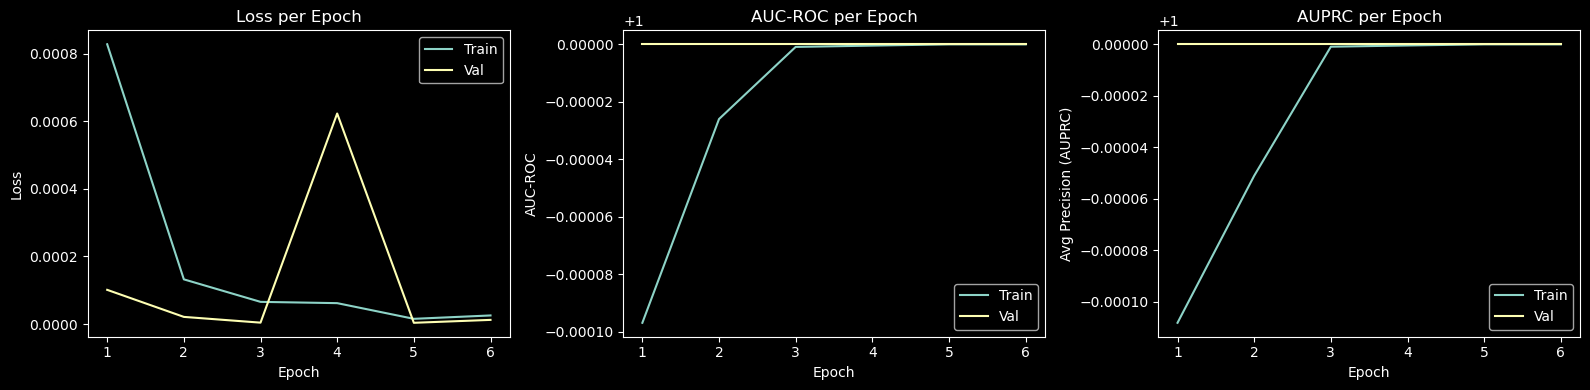

In [13]:
epochs_ran = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (tr_key, vl_key), title, ylabel in zip(
    axes,
    [("train_loss","val_loss"), ("train_auc","val_auc"), ("train_auprc","val_auprc")],
    ["Loss", "AUC-ROC", "AUPRC"],
    ["Loss", "AUC-ROC", "Avg Precision (AUPRC)"]
):
    ax.plot(epochs_ran, history[tr_key], label="Train")
    ax.plot(epochs_ran, history[vl_key], label="Val")
    ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.set_title(f"{title} per Epoch"); ax.legend()

plt.tight_layout()
plt.show()

## Decision Threshold Calibration

### Why Not Use 0.5?

With a severe class imbalance (~98% benign), a model trained even with Focal Loss and balanced sampling may output calibrated probabilities that do not align with the 0.5 midpoint. A threshold of 0.5 often produces very high specificity (few false positives) but very low sensitivity (many missed malignancies) — the wrong trade-off for a medical screening task where missing a malignant case is far more costly.

By sweeping thresholds over the **validation set** and selecting the one that maximises the **F1 score** (harmonic mean of precision and recall), we find the threshold that best balances sensitivity and specificity for this specific model and dataset distribution.

Val inference:   0%|          | 0/2507 [00:00<?, ?it/s]

Optimal threshold (max val F1): 0.930  →  F1 = 1.0000


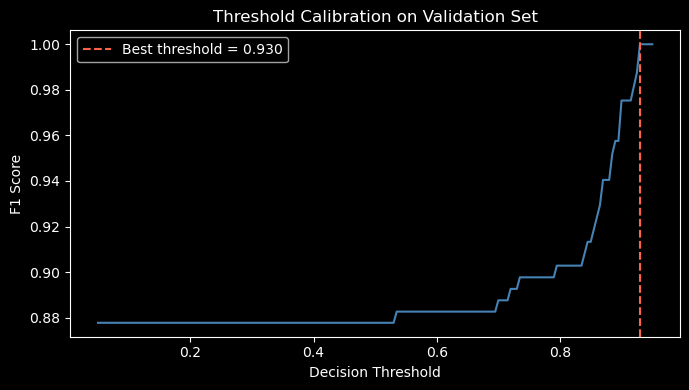

In [14]:
# ── Load best checkpoint and collect val probabilities ────────────────────
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

val_labels, val_probs = [], []
with torch.no_grad():
    for images, meta, labels in tqdm(val_loader, desc="Val inference", leave=False):
        images = images.to(DEVICE, non_blocking=True)
        meta   = move_meta(meta, DEVICE)
        logits = model(images, meta)
        val_probs.extend(torch.sigmoid(logits).cpu().numpy())
        val_labels.extend(labels.numpy())

val_labels = np.array(val_labels)
val_probs  = np.array(val_probs)

# ── Sweep thresholds to find best F1 ─────────────────────────────────────
thresholds = np.linspace(0.05, 0.95, 181)
f1_scores  = [f1_score(val_labels, (val_probs >= t).astype(int), zero_division=0)
              for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]
best_f1     = max(f1_scores)

print(f"Optimal threshold (max val F1): {best_thresh:.3f}  →  F1 = {best_f1:.4f}")

# ── Plot threshold vs F1 ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, f1_scores, color="steelblue")
ax.axvline(best_thresh, color="tomato", linestyle="--",
           label=f"Best threshold = {best_thresh:.3f}")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("F1 Score")
ax.set_title("Threshold Calibration on Validation Set")
ax.legend()
plt.tight_layout()
plt.show()

## Evaluation on Test Set

Metrics reported:
- **AUC-ROC** — threshold-independent ranking metric
- **AUPRC** — precision-recall AUC, the primary metric for severe class imbalance
- **Accuracy, Precision, Recall, F1** — at the calibrated threshold
- **Confusion matrix** and **ROC + PR curves**

Test inference:   0%|          | 0/2507 [00:00<?, ?it/s]

              TEST SET RESULTS
  AUC-ROC   : 1.0000
  AUPRC     : 1.0000   ← primary metric (imbalanced data)
  Threshold : 0.930  (calibrated on val set)
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1 Score  : 1.0000

Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     80134
   Malignant       1.00      1.00      1.00        78

    accuracy                           1.00     80212
   macro avg       1.00      1.00      1.00     80212
weighted avg       1.00      1.00      1.00     80212



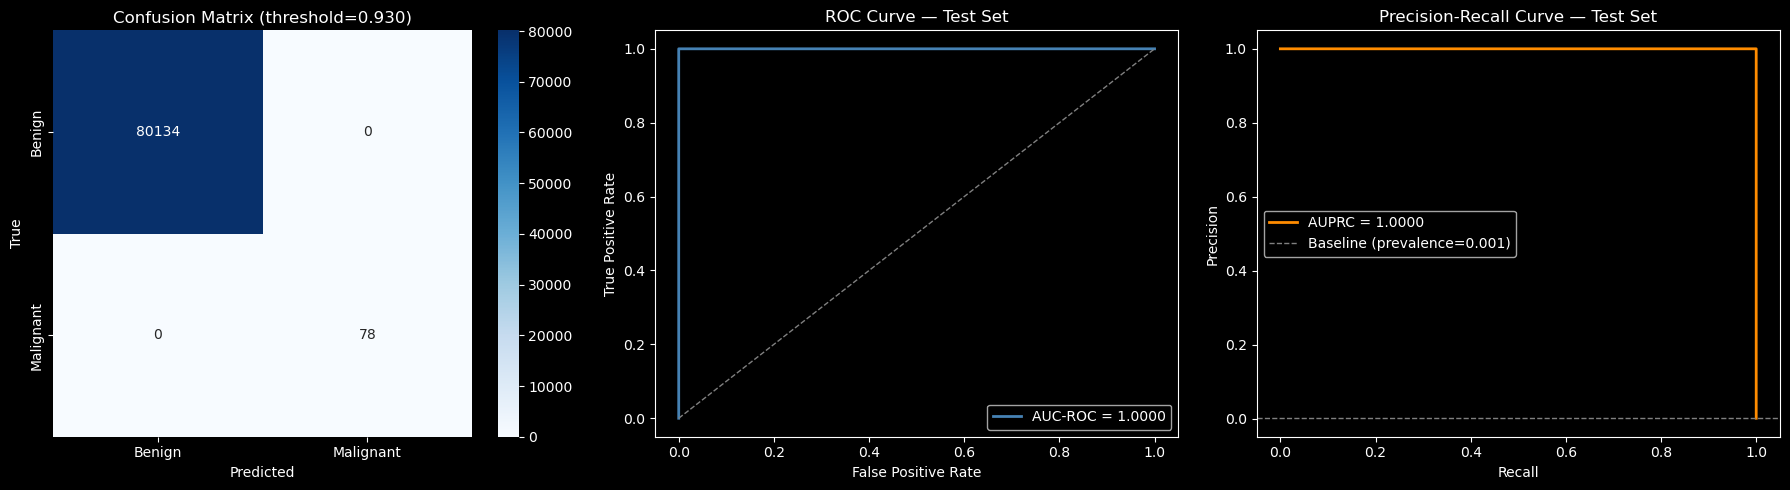

In [15]:
# ── Collect test set predictions ──────────────────────────────────────────
test_labels, test_probs = [], []
with torch.no_grad():
    for images, meta, labels in tqdm(test_loader, desc="Test inference", leave=False):
        images = images.to(DEVICE, non_blocking=True)
        meta   = move_meta(meta, DEVICE)
        logits = model(images, meta)
        test_probs.extend(torch.sigmoid(logits).cpu().numpy())
        test_labels.extend(labels.numpy())

test_labels = np.array(test_labels)
test_probs  = np.array(test_probs)
test_preds  = (test_probs >= best_thresh).astype(int)

# ── Scalar metrics ─────────────────────────────────────────────────────────
test_auc   = roc_auc_score(test_labels, test_probs)
test_auprc = average_precision_score(test_labels, test_probs)
test_acc   = accuracy_score(test_labels, test_preds)
test_prec  = precision_score(test_labels, test_preds, zero_division=0)
test_rec   = recall_score(test_labels, test_preds, zero_division=0)
test_f1    = f1_score(test_labels, test_preds, zero_division=0)

print("=" * 60)
print("              TEST SET RESULTS")
print("=" * 60)
print(f"  AUC-ROC   : {test_auc:.4f}")
print(f"  AUPRC     : {test_auprc:.4f}   ← primary metric (imbalanced data)")
print(f"  Threshold : {best_thresh:.3f}  (calibrated on val set)")
print(f"  Accuracy  : {test_acc:.4f}")
print(f"  Precision : {test_prec:.4f}")
print(f"  Recall    : {test_rec:.4f}")
print(f"  F1 Score  : {test_f1:.4f}")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(test_labels, test_preds,
                            target_names=["Benign", "Malignant"]))

# ── Confusion matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(test_labels, test_preds)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign","Malignant"],
            yticklabels=["Benign","Malignant"], ax=axes[0])
axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")
axes[0].set_title(f"Confusion Matrix (threshold={best_thresh:.3f})")

# ── ROC curve ─────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(test_labels, test_probs)
axes[1].plot(fpr, tpr, color="steelblue", lw=2,
             label=f"AUC-ROC = {test_auc:.4f}")
axes[1].plot([0,1],[0,1], color="gray", lw=1, linestyle="--")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve — Test Set"); axes[1].legend(loc="lower right")

# ── Precision-Recall curve ────────────────────────────────────────────────
prec_arr, rec_arr, _ = precision_recall_curve(test_labels, test_probs)
axes[2].plot(rec_arr, prec_arr, color="darkorange", lw=2,
             label=f"AUPRC = {test_auprc:.4f}")
axes[2].axhline(test_labels.mean(), color="gray", lw=1, linestyle="--",
                label=f"Baseline (prevalence={test_labels.mean():.3f})")
axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve — Test Set"); axes[2].legend()

plt.tight_layout()
plt.show()